In [1]:
from pymatgen.core import Structure
from joblib import Memory
from mp_api.client import MPRester
from ase.visualize import view
import numpy as np

memory = Memory('.cachedir')

In [2]:
def view_structure(structure, viewer='ase'):
    return view(structure.to_ase_atoms(), viewer=viewer)

@memory.cache
def get_structure(mp_id):
    with MPRester() as mpr:
        # docs = mpr.materials.summary.search(material_ids=[mp_id], fields=["structure"])
        # structure = docs[0].structure
        # # -- Shortcut for a single Materials Project ID:
        structure = mpr.get_structure_by_material_id(mp_id,)
    
    return structure

structure = get_structure('mp-1265')
structure = structure.to_conventional()

In [3]:
from pymatgen.core.structure import Structure
from pymatgen.core.surface import SlabGenerator
from pymatgen.io.vasp.inputs import Poscar

slab_gen = SlabGenerator(structure, [1,1,1], 50, 10, primitive=True) ### If you want the slab to be center set center_slab=True
slab = slab_gen.get_slab()
view_structure(slab)
view_structure(slab.oriented_unit_cell)

<Popen: returncode: None args: ['/Users/tw/miniforge3/envs/surfpes/bin/pytho...>

## Monkeypatch Calculation of Required Surface Charge

In [4]:
from pymatgen.core.surface import Slab

def get_dipole_density_per_ouc(self):
    ouc = self.oriented_unit_cell.copy()
    ouc = ouc.add_oxidation_state_by_guess()
    centroid = np.sum(ouc.cart_coords, axis=0) / len(ouc)

    dipole = np.zeros(3)
    for site in ouc:
        charge = sum(getattr(sp, "oxi_state", 0) * amt for sp, amt in site.species.items())
        dipole += charge * np.dot(site.coords - centroid, self.normal) * self.normal 
        # TODO: we only want to deal with slabs with a normal along the c-axis
    
    return dipole / ouc.volume

@property
def required_surface_charge(self):
    dipole = get_dipole_density_per_ouc(self)
    return np.dot(dipole, self.normal) * self.surface_area

def move_to_back(self, site_idx):
    self.sites[site_idx].cart_coords[2] = self.sites[site_idx].cart_coords[2] - self.num_layers * self.oriented_unit_cell.lattice.matrix[2]

Slab.get_dipole_density_per_ouc = get_dipole_density_per_ouc
Slab.required_surface_charge = required_surface_charge

slab.required_surface_charge

np.float64(-4.000000000000002)

In [5]:
def stabilize_via_move(self):
    '''
    This may be broken if coordinates aren't wrapped.
    '''
    # TODO: ions with multiple oxidation states
    target_charge = np.absself.required_surface_charge
    oxi_state_guesses = self.oriented_unit_cell.comp.get_oxi_state_guesses()[0]
    possible_charge_change = []

    distance_along_normal = np.dot(self.sites[0].cart_coords, self.normal) # TODO: could use coordination instead
    top_distance_along_normal = max(distance_along_normal)
    bottom_distance_along_normal = min(distance_along_normal)
    
    top_sites = (top_distance_along_normal - distance_along_normal) < 1.5
    bottom_sites = (distance_along_normal - bottom_distance_along_normal) < 1.5

    

    for charge in oxi_state_guesses.values():
        possible_charge_change.append(charge)
        possible_charge_change.append(-charge)

    # bezouts identity
    gcd = np.gcd.reduce(list(oxi_state_guesses.values()))
    gcd / target_charge


    


    
    


In [6]:
slab.required_surface_charge

np.float64(-4.000000000000002)

In [7]:
slab.oriented_unit_cell.lattice.matrix[2]

array([0.        , 0.        , 4.19400279])

In [8]:
slab.lattice.matrix

array([[ 4.19400279e+00,  0.00000000e+00, -4.19400279e+00],
       [ 1.60570278e-15,  4.19400279e+00, -4.19400279e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.09044072e+02]])

In [9]:
slab.oriented_unit_cell.composition.oxi_state_guesses??

Signature:
slab.oriented_unit_cell.composition.oxi_state_guesses(
    oxi_states_override: 'dict | None' = None,
    target_charge: 'float' = 0,
    all_oxi_states: 'bool' = False,
    max_sites: 'int | None' = None,
) -> 'tuple'
Source:   
    def oxi_state_guesses(
        self,
        oxi_states_override: dict | None = None,
        target_charge: float = 0,
        all_oxi_states: bool = False,
        max_sites: int | None = None,
    ) -> tuple:
        """Check if the composition is charge-balanced and returns back all
        charge-balanced oxidation state combinations. Composition must have
        integer values. Note that more num_atoms in the composition gives
        more degrees of freedom. e.g. if possible oxidation states of
        element X are [2,4] and Y are [-3], then XY is not charge balanced
        but X2Y2 is. Results are returned from most to least probable based
        on ICSD statistics. Use max_sites to improve performance if needed.

        Args:
     

In [10]:
slab.oriented_unit_cell.add_oxidation_state_by_guess(target_charge=10)

Structure Summary
Lattice
    abc : 5.931215619675673 5.931215619675673 4.1940027853522395
 angles : 135.0 135.0 59.99999999999999
 volume : 73.77108036409368
      A : np.float64(4.1940027853522395) np.float64(0.0) np.float64(-4.194002785352239)
      B : np.float64(1.6057027787212026e-15) np.float64(4.1940027853522395) np.float64(-4.194002785352239)
      C : np.float64(0.0) np.float64(0.0) np.float64(4.1940027853522395)
    pbc : True True True
PeriodicSite: Mg_1 (Mg0+) (0.0, 0.0, 0.0) [0.0, 0.0, 0.0]
PeriodicSite: Mg_2 (Mg0+) (2.097, 2.097, -4.194) [0.5, 0.5, 0.0]
PeriodicSite: Mg_3 (Mg0+) (8.029e-16, 2.097, -2.097) [0.0, 0.5, 0.0]
PeriodicSite: Mg_4 (Mg0+) (2.097, 2.568e-16, -2.097) [0.5, 6.123e-17, 0.0]
PeriodicSite: O_1 (O0+) (8.029e-16, 2.097, 4.441e-16) [0.0, 0.5, 0.5]
PeriodicSite: O_2 (O0+) (2.097, 1.284e-16, 3.157e-16) [0.5, 3.062e-17, 0.5]
PeriodicSite: O_3 (O0+) (4.916e-32, 1.284e-16, 2.097) [0.0, 3.062e-17, 0.5]
PeriodicSite: O_4 (O0+) (2.097, 2.097, -2.097) [0.5, 0.5, 0

In [11]:
import pulp

def solve_weights(a, t, can_neg, can_pos):
    n = len(a)
    prob = pulp.LpProblem("weights")

    w = []


    
    for i in range(n):
        lb = -1 if can_neg[i] else 0
        ub =  1 if can_pos[i] else 0
        w.append(pulp.LpVariable(f"w{i}", lb, ub, cat="Integer"))

    prob += sum(w[i] * a[i] for i in range(n)) == t
    prob.solve()

    return [int(v.value()) for v in w]

In [12]:
a = [3,5,7]

can_neg = [True, False, True]   # atom 1 cannot be -1
can_pos = [True, True, False]   # atom 2 cannot be +1

solve_weights(a, 2, can_neg, can_pos)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/tw/miniforge3/envs/surfpes/lib/python3.11/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/v4/9mn3h1611vn857k_73b_dx4w0000gn/T/b328a27ac47f49bb90c9aa33fb82a39b-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/v4/9mn3h1611vn857k_73b_dx4w0000gn/T/b328a27ac47f49bb90c9aa33fb82a39b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 6 COLUMNS
At line 17 RHS
At line 19 BOUNDS
At line 26 ENDATA
Problem MODEL has 1 rows, 4 columns and 3 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.00 seconds
Cgl0003I 2 fixed, 1 tightened bounds, 0 strengthened rows, 0 substitutions
Cgl0004I processed model has 0 rows, 0 columns (0 integer (0 of which binary)) and 0 elements
Cbc3007W No integer variables - nothing to do
Cuts at root node changed objective fr

[-1, 1, 0]

In [13]:
import pulp


def solve_lexicographic_with_pulp(
    values,
    target,
    depth_if_pos,   # cost if w_i = +1
    depth_if_neg,   # cost if w_i = -1
    can_be_pos,
    can_be_neg,
    msg=False,
):
    n = len(values)

    problem = pulp.LpProblem("surface_move_choice", pulp.LpMinimize)

    move_pos = [
        pulp.LpVariable(f"move_pos_{i}", lowBound=0, upBound=1, cat="Binary")
        for i in range(n)
    ]
    move_neg = [
        pulp.LpVariable(f"move_neg_{i}", lowBound=0, upBound=1, cat="Binary")
        for i in range(n)
    ]
    moved = [
        pulp.LpVariable(f"atom_moved_{i}", lowBound=0, upBound=1, cat="Binary")
        for i in range(n)
    ]

    for i in range(n):
        if not can_be_pos[i]:
            problem += move_pos[i] == 0
        if not can_be_neg[i]:
            problem += move_neg[i] == 0

        problem += move_pos[i] + move_neg[i] <= 1
        problem += moved[i] == move_pos[i] + move_neg[i]

    problem += pulp.lpSum(
        values[i] * (move_pos[i] - move_neg[i]) for i in range(n)
    ) == target

    solver = pulp.PULP_CBC_CMD(msg=msg)

    # Stage 1: minimize number of moved ions
    move_count = pulp.lpSum(moved)
    problem.objective = move_count
    problem.solve(solver)

    best_move_count = int(round(pulp.value(move_count)))
    problem += move_count == best_move_count

    # Stage 2: among min-move solutions, minimize direction-specific depth cost
    depth_cost = pulp.lpSum(
        depth_if_pos[i] * move_pos[i] + depth_if_neg[i] * move_neg[i]
        for i in range(n)
    )
    problem.objective = depth_cost
    problem.solve(solver)

    weights = [
        int(round(pulp.value(move_pos[i]) - pulp.value(move_neg[i])))
        for i in range(n)
    ]

    return {
        "weights": weights,
        "moved_count": sum(1 for w in weights if w != 0),
        "depth_cost": float(pulp.value(depth_cost)),
    }

In [14]:
solve_lexicographic_with_pulp(
    values=[3,5,7],
    target=2,
    depth_if_pos=[0,1,2],
    depth_if_neg=[0,1,2],
    can_be_pos=[True, True, False],
    can_be_neg=[True, False, True],)

{'weights': [-1, 1, 0], 'moved_count': 2, 'depth_cost': 1.0}

In [15]:
import pulp


def solve_best_effort_depth_first_with_pulp(
    values,
    target,
    depth_if_pos,   # cost if w_i = +1
    depth_if_neg,   # cost if w_i = -1
    can_be_pos=None,
    can_be_neg=None,
    msg=False,
    solver=None,
):
    """
    Solve for w_i in {-1,0,1} (via binaries) with lexicographic priorities:
      1) minimize |sum(values_i * w_i) - target|
      2) among those, minimize direction-specific depth cost

    Returns a dict containing weights, achieved_sum, residual, depth_cost, residual_abs.
    """

    if solver is None:
        solver = pulp.PULP_CBC_CMD(msg=msg)


    n = len(values)

    problem = pulp.LpProblem("best_effort_surface_move_choice", pulp.LpMinimize)

    choose_pos = [pulp.LpVariable(f"choose_pos_{i}", 0, 1, cat="Binary") for i in range(n)]
    choose_neg = [pulp.LpVariable(f"choose_neg_{i}", 0, 1, cat="Binary") for i in range(n)]

    for i in range(n):
        if (can_be_neg is not None) and not can_be_pos[i]:
            problem += choose_pos[i] == 0
        if (can_be_pos is not None) and not can_be_neg[i]:
            problem += choose_neg[i] == 0

        problem += choose_pos[i] + choose_neg[i] <= 1

    achieved_sum = pulp.lpSum(values[i] * (choose_pos[i] - choose_neg[i]) for i in range(n))

    residual_pos = pulp.LpVariable("residual_pos", lowBound=0)
    residual_neg = pulp.LpVariable("residual_neg", lowBound=0)
    problem += achieved_sum - target == residual_pos - residual_neg

    residual_abs = residual_pos + residual_neg

    depth_cost = pulp.lpSum(
        depth_if_pos[i] * choose_pos[i] + depth_if_neg[i] * choose_neg[i]
        for i in range(n)
    )

    # Stage 1: minimize absolute residual
    problem.objective = residual_abs
    problem.solve(solver)

    best_residual_abs = float(pulp.value(residual_abs))
    problem += residual_abs == best_residual_abs

    # Stage 2: among min-residual solutions, minimize depth cost
    problem.objective = depth_cost
    problem.solve(solver)

    weights = [
        int(round(pulp.value(choose_pos[i]) - pulp.value(choose_neg[i])))
        for i in range(n)
    ]

    achieved = float(pulp.value(achieved_sum))
    residual = achieved - float(target)
    depth_value = float(pulp.value(depth_cost))

    return {
        "weights": weights,
        "achieved_sum": achieved,
        "target": float(target),
        "residual": residual,
        "residual_abs": abs(residual),
        "depth_cost": depth_value,
    }

In [16]:
solve_best_effort_depth_first_with_pulp(
    values=[3,5,7],
    target=2,
    depth_if_pos=[0,1,2],
    depth_if_neg=[2,1,2],
    can_be_pos=[True, True, False],
    can_be_neg=[True, False, True],
)

{'weights': [-1, 1, 0],
 'achieved_sum': 2.0,
 'target': 2.0,
 'residual': 0.0,
 'residual_abs': 0.0,
 'depth_cost': 3.0}

In [17]:
def process_uoc_linear_programming(slab):
    uoc = slab.oriented_unit_cell.copy()
    np.testing.assert_allclose(uoc.lattice.matrix[:2], slab.lattice.matrix[:2], err_msg="Lattice mismatch between UOC and slab")
    tol = 1e-6
    assert np.linalg.norm(np.cross(uoc.lattice.matrix[2], slab.lattice.matrix[2])) < tol, "Lattice mismatch between UOC and slab"

    distance_along_normal = np.dot(uoc.cart_coords, slab.normal)
    top_depth = max(distance_along_normal)
    bottom_depth = min(distance_along_normal)

    distance_from_top = top_depth - distance_along_normal
    distance_from_bottom = distance_along_normal - bottom_depth

    uoc.add_oxidation_state_by_guess()
    oxidation_states = [sp.oxi_state for sp in uoc.species]

    return {
        "distance_from_top": distance_from_top,
        "distance_from_bottom": distance_from_bottom,
        "oxidation_states": oxidation_states,
    }


In [18]:
def ouc_site_to_slab_site_idx(self, ouc_site_idx, bottom=True):
    if bottom:
        return ouc_site_idx
    else:
        return len(self) - len(slab.oriented_unit_cell) + ouc_site_idx
    
def move_to_other_side(self, ouc_site_idx, bottom=True):
    site_idx = self.ouc_site_to_slab_site_idx(ouc_site_idx, bottom=bottom)
    
    self.sites[site_idx].coords += \
        (1 if bottom else -1) * self.num_layers * self.oriented_unit_cell.lattice.matrix[2]
    
Slab.ouc_site_to_slab_site_idx = ouc_site_to_slab_site_idx
Slab.move_to_other_side = move_to_other_side

In [19]:
len(slab) // len(slab.oriented_unit_cell)

21

In [20]:
slab_inputs = process_uoc_linear_programming(slab)
solution = solve_best_effort_depth_first_with_pulp(
    values=slab_inputs["oxidation_states"],
    target=slab.required_surface_charge,
    depth_if_pos=slab_inputs["distance_from_top"],
    depth_if_neg=slab_inputs["distance_from_bottom"],
)

for ouc_site_idx, weight in enumerate(solution['weights']):
    print(f"Site {ouc_site_idx}: weight {weight}")
    if weight == 1:
        slab.move_to_other_side(ouc_site_idx, bottom=False)
    elif weight == -1:
        slab.move_to_other_side(ouc_site_idx, bottom=True)

Site 0: weight 0
Site 1: weight -1
Site 2: weight 0
Site 3: weight 0
Site 4: weight 0
Site 5: weight 1
Site 6: weight 0
Site 7: weight 0


/var/folders/v4/9mn3h1611vn857k_73b_dx4w0000gn/T/ipykernel_49174/2367834977.py:22: RuntimeWarning: invalid value encountered in log
  log_minus_energies = np.log(energies)


ValueError: x and y must have same first dimension, but have shapes (10,) and (1,)

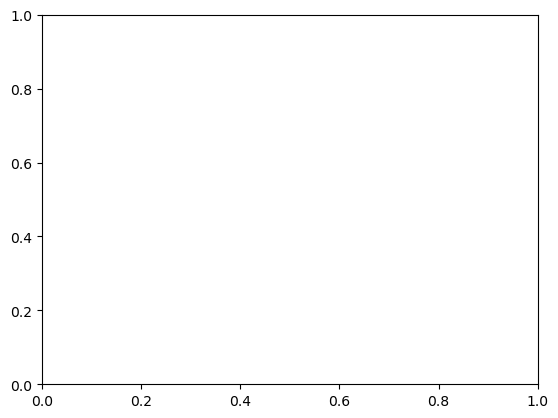

In [22]:
from pymatgen.analysis.energy_models import EwaldElectrostaticModel
from matplotlib import pyplot as plt

vacuums = np.linspace(10, 10000, 10)
log_v = [np.log(v) for v in vacuums]
energies = []
model = EwaldElectrostaticModel()



for v in vacuums:
    v=100
    slab_gen_v = SlabGenerator(structure, [1,1,1], 50, min_vacuum_size=v, primitive=True)
    slab_v = slab_gen_v.get_slab()
    slab_v.add_oxidation_state_by_guess()
    # print(slab_v.lattice.abc)
    E = model.get_energy(slab_v)
    energies.append(E)
    break

# energies = np.array(energies) - energies[-1]  # normalize to the largest vacuum energy
log_minus_energies = np.log(energies)

plt.plot(vacuums, energies)
# plt.plot(log_v, log_minus_energies)